In [1]:
from IndividualParcellation.global_config import *
import numpy as np
import pandas as pd
import nitools as nt
import seaborn as sns
import SUITPy.flatmap as flatmap
import matplotlib.pyplot as plt
import nilearn.plotting as plotting
from Functional_Fusion.dataset import DataSetMDTB
import Functional_Fusion.atlas_map as am
from OptimalBattery.util import align_conditions, find_optimal_battery

No protocol specified


# Constants

For this analysis , I will use a mask that includes D + S regions

In [2]:
# Define ROIs to be used for the analysis
base_dir = '/cifs/diedrichsen/data/FunctionalFusion'
ROI_cerebellum=['S1L', 'S1R', 'S2L', 'S2R', 'S3L', 'S3R', 'S4L', 'S4R','D1L', 'D1R', 'D2L', 'D2R', 'D3L', 'D3R', 'D4L', 'D4R']
ROI_cortex = [2,3,4,5,6,7] # only used if space is fs32k
space = 'fs32k'
atlas, _ = am.get_atlas(space)

In [3]:
# Check if CUDA is available
device = pt.device('cuda' if pt.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


# Step 1: Load group parcellations for ROI specific analysis

In [4]:
if space == 'fs32k':
    atlas_dir = f'{base_dir}/Atlases/tpl-fs32k'
    model_name_L = f'{atlas_dir}/yeo7.L.label.gii'
    model_name_R = f'{atlas_dir}/yeo7.R.label.gii'

    yeo_parcels = atlas.read_data([model_name_L,model_name_R])
    ROI_mask = np.isin(yeo_parcels, ROI_cortex).astype(int)

elif space == 'SUIT3':
    atlas_dir = f'{base_dir}/Atlases/tpl-SUIT'
    model_name = f'/atl-NettekovenSym32_space-SUIT_dseg.nii'
    U = atlas.read_data(atlas_dir + model_name)
    U = U.T
    _, cmap, labels = nt.read_lut(f'{atlas_dir}/atl-NettekovenSym32.lut')
    ROI_mask = np.zeros_like(U)
    for i, label in enumerate(labels):
        if label in ROI_cerebellum:
            ROI_mask[U == i] = 1

else:
    print('atlas space not supported')

# Sanity check: Plot ROI

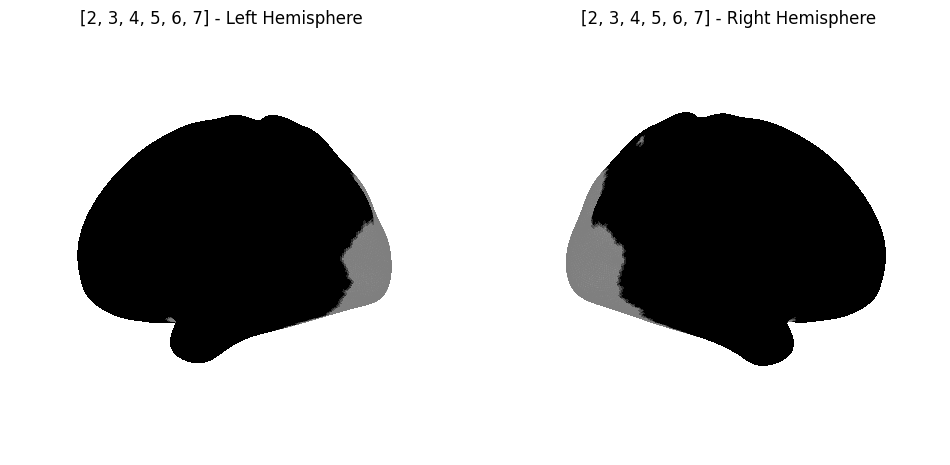

In [5]:
if space == 'fs32k':
    surfs = [base_dir+ "/Atlases" + f'/tpl-fs32k/tpl-fs32k_hemi-{h}_inflated.surf.gii' for i, h in enumerate(['L', 'R'])]
    mask_reshaped = ROI_mask[np.newaxis, :]  # Reshape to (1, 59518)

    # Convert to CIFTI format
    cifti = atlas.data_to_cifti(mask_reshaped)

    # Extract the data for the cortical surfaces
    all_img = nt.surf_from_cifti(cifti)

    # Plot cortical maps for left and right hemispheres
    fig, axes = plt.subplots(1, 2, subplot_kw={'projection': '3d'}, figsize=(12, 6))
    for h, hemi in enumerate(['left', 'right']):
        plotting.plot_surf_stat_map(
            surfs[h], all_img[h], hemi=hemi,
            colorbar=False,
            cmap='binary',
            axes=axes[h],
            threshold = 0.1,
            title=f"{ROI_cortex} - {hemi.capitalize()} Hemisphere")

elif space =='SUIT3':
    lang_img = atlas.data_to_nifti(ROI_mask)
    surface = flatmap.vol_to_surf(lang_img, space='SUIT',stats = 'mode')
    flatmap.plot(data=surface, new_figure=True, colorbar=True, render='matplotlib')

else:
    print('not supported')

# Step 2a: Load datasets for search algorithm

Here I'm using MDTB-s1 for search algorithm

In [6]:
MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s1,info_mdtb_1  =MDTB_dataset.get_data(space=space,ses_id='ses-s1',type='CondRun')

MDTB_dataset = DataSetMDTB(f'{base_dir}/MDTB')
data_mdtb_s2,info_mdtb_2  =MDTB_dataset.get_data(space=space,ses_id='ses-s2',type='CondRun')

align datasets

In [7]:
unique_runs = np.intersect1d(info_mdtb_1['run'].unique(), info_mdtb_2['run'].unique())
print(f"Unique runs: {unique_runs}")

# Initialize lists to store combined data and info for each run
combined_data_list = []
combined_info_list = []

for run in unique_runs:
    print(f"Processing run: {run}")
    run_idx_a = info_mdtb_1['run'] == run
    run_idx_b = info_mdtb_2['run'] == run

    # Extract the run-specific data from Datasets
    run_data_a = data_mdtb_s1[:, run_idx_a, :]  
    run_data_b = data_mdtb_s2[:, run_idx_b, :]  

    # Get corresponding info for the current run
    run_info_a = info_mdtb_1[run_idx_a].reset_index(drop=True)  
    run_info_b = info_mdtb_2[run_idx_b].reset_index(drop=True)  

    # Align conditions 
    aligned_data, combined_info = align_conditions(run_data_a, run_data_b, run_info_a, run_info_b)
    combined_info['run'] = run

    # Store the aligned data and combined info for the current run
    combined_data_list.append(aligned_data)
    combined_info_list.append(combined_info)

# Concatenate all runs' data along the condition axis and all info along rows
final_combined_data = np.concatenate(combined_data_list, axis=1)
final_combined_info = pd.concat(combined_info_list, ignore_index=True)

    


Unique runs: [ 1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16]
Processing run: 1
Processing run: 2
Processing run: 3
Processing run: 4
Processing run: 5
Processing run: 6
Processing run: 7
Processing run: 8
Processing run: 9
Processing run: 10
Processing run: 11
Processing run: 12
Processing run: 13
Processing run: 14
Processing run: 15
Processing run: 16


In [8]:
final_combined_data.shape

(24, 752, 59518)

In [9]:
task_matrix = final_combined_data * ROI_mask
task_names = final_combined_info.cond_name.values

In [14]:
len(task_names)

752

# Step 3: Run search algorithm

In [10]:
# Run the algorithm to find top combinations
top_combinations = find_optimal_battery(
    task_matrix, 
    task_names, 
    num_tasks=8, 
    function='determinant', 
    top_n=100, 
    sample_size=30000000,
    average_across_subjects=False
)

combined_list = []

# Print the top combinations with their corresponding task names
for i, (value, comb) in enumerate(top_combinations, start=1):
    combo_task_names = [final_combined_info.cond_name.values[index] for index in comb]
    combined_list.append(combo_task_names)
    print(f'Combination {i}:', combo_task_names)

Processing sample 1/30000000
Processing sample 100001/30000000
Processing sample 200001/30000000
Processing sample 300001/30000000
Processing sample 400001/30000000
Processing sample 500001/30000000
Processing sample 600001/30000000
Processing sample 700001/30000000
Processing sample 800001/30000000
Processing sample 900001/30000000
Processing sample 1000001/30000000
Processing sample 1100001/30000000
Processing sample 1200001/30000000
Processing sample 1300001/30000000
Processing sample 1400001/30000000
Processing sample 1500001/30000000
Processing sample 1600001/30000000
Processing sample 1700001/30000000
Processing sample 1800001/30000000
Processing sample 1900001/30000000
Processing sample 2000001/30000000
Processing sample 2100001/30000000
Processing sample 2200001/30000000
Processing sample 2300001/30000000
Processing sample 2400001/30000000
Processing sample 2500001/30000000
Processing sample 2600001/30000000
Processing sample 2700001/30000000
Processing sample 2800001/30000000


In [11]:
all_tasks = [task for combo in combined_list for task in combo]


(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
        34]),
 [Text(0, 0, 'MotorImagery'),
  Text(1, 0, 'RomanceMovie'),
  Text(2, 0, 'VerbGen'),
  Text(3, 0, 'MentalRotDiff'),
  Text(4, 0, 'PleasantScenes'),
  Text(5, 0, 'Verbal0Back'),
  Text(6, 0, 'VideoAct'),
  Text(7, 0, 'FingerSeq'),
  Text(8, 0, 'SpatialMedDiff'),
  Text(9, 0, 'UnpleasantScenes'),
  Text(10, 0, 'ToM'),
  Text(11, 0, 'Verbal2Back'),
  Text(12, 0, 'Go'),
  Text(13, 0, 'Math'),
  Text(14, 0, 'rest'),
  Text(15, 0, 'SpatialMapMed'),
  Text(16, 0, 'IntervalTiming'),
  Text(17, 0, 'SpatialNavigation'),
  Text(18, 0, 'VisualSearchMed'),
  Text(19, 0, 'MentalRotMed'),
  Text(20, 0, 'NoGo'),
  Text(21, 0, 'DigitJudgement'),
  Text(22, 0, 'HappyFaces'),
  Text(23, 0, 'BodyMotionIntact'),
  Text(24, 0, 'Object2Back'),
  Text(25, 0, 'StroopCon'),
  Text(26, 0, 'VideoKnots'),
  Text(27, 0, 'BodyMotionScram'),
  Text(28, 0

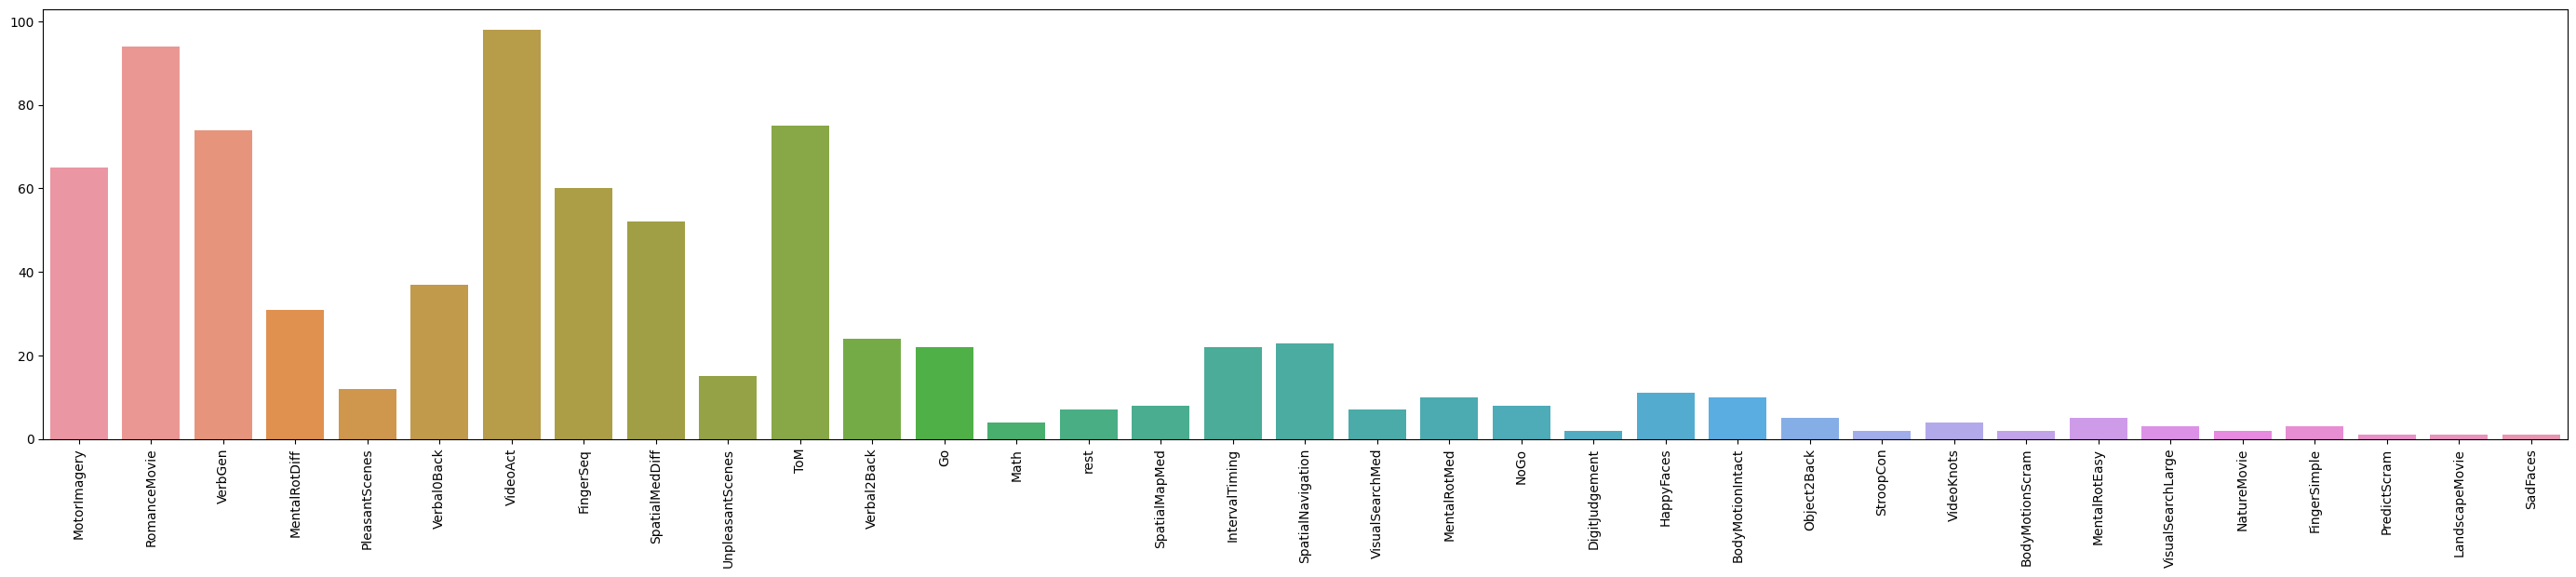

In [13]:
from collections import Counter

#count the frequences of each task
task_freq = Counter(all_tasks)

#plot the frequencies
plt.figure(figsize=(35, 6))
sns.barplot(x=list(task_freq.keys()), y=list(task_freq.values()))
plt.xticks(rotation=90)
